## HPC AI Lab 1: Baseline - revisited

## Preparing the data
The first step is to get the data the model will be using. As the task says, we must use the SQuAD (The Stanford Question Answering Dataset). With the next commands we can easily download it (or from [the web](https://rajpurkar.github.io/SQuAD-explorer/)):

This dataset consists of 100k questions on a set of Wikipedia articles where the answer to every question is a segment of text, or span, from the corresponding reading passage. In this second version of SQuAD, 50k unanswerable questions were added to look similar to answerable ones. Using this second version, the goal of the model must be not only answer questions when possible, but also determine when no answer is supported by the paragraph and abstain from answering.

We also need the transformers library for later use.

In [1]:
# %%capture
# !mkdir dataset
# !wget https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v2.0.json -O dataset/train.json
# !wget https://rajpurkar.github.io/SQuAD-explorer/dataset/dev-v2.0.json -O dataset/dev.json
# !pip install transformers
# !pip install torch

## Importing necessary libraries

In [2]:
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import time
from transformers import AutoTokenizer,BertForQuestionAnswering
import torch_optimizer as optim_lookahead
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt


/mnt/netapp2/Store_uni/home/ulc/cursos/curso361/mypython/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-24 01:37:54.109531: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-24 01:38:03.654715: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-24 01:38:16.273723: W tensorflow/compiler/xla/

## Getting the dataset ready
#### 1. Loading the data from the files

Here I take and store the texts, queries and answers from the train and validation .json files. If we look carefully we will see that in these files there are a number of queries and answers for each passage. I save these informations into lists.

In [3]:
# Get the train data
path = Path('dataset/train.json')
with open(path, 'rb') as f:
    train_dict = json.load(f)

context_lst = []
question_lst = []
answer_lst = []

# For each context, get its question and its answer
for group in train_dict['data']:
    for passage in group['paragraphs']:
        context = passage['context']
        for qa in passage['qas']:
            question = qa['question']
            for answer in qa['answers']:
                # Store them in their respective lists
                context_lst.append(context)
                question_lst.append(question)
                answer_lst.append(answer)

train_contexts, train_questions, train_answers = context_lst, question_lst, answer_lst

# Do the same for the validation data
path = Path('dataset/dev.json')
with open(path, 'rb') as f:
    data_dict = json.load(f)

context_lst = []
question_lst = []
answer_lst = []

# Search for each passage, its question and its answer
for group in data_dict['data']:
    for passage in group['paragraphs']:
        context = passage['context']
        for qa in passage['qas']:
            question = qa['question']
            for answer in qa['answers']:
                # Store every passage, query and its answer to the lists
                context_lst.append(context)
                question_lst.append(question)
                answer_lst.append(answer)

val_contexts, val_questions, val_answers = context_lst, question_lst, answer_lst

#### 2. Checking the data
We have around 86k passages, queries and answers from the training data, and around 20k for validation data. The answer is stored in a dictionary with the specific answer in the "text" cell and the accurate character index that the answer is started in cell "answer start". As we observe, is missing the information about the exact index of the character that the answer is ending.

For faster execution (it took VERY long with the whole dataset), I chose the first 10k and 2k entries from the train and evaluation data respectively.

In [4]:
print("There are ",len(train_contexts), "train_contexts")
print("There are ",len(train_questions), "train_contexts")
print("There are ",len(train_answers), "train_contexts")
print("\nAn example: ")
print("\tPassage: ",train_contexts[0])
print("\tQuery: ",train_questions[0])
print("\tAnswer: ",train_answers[0])

print("----------------")

print("There are ",len(val_contexts), "val_contexts")
print("There are ",len(val_questions), "val_questions")
print("There are ",len(val_answers), "val_answers")
print("\nAn example: ")
print("\tPassage: ",val_contexts[0])
print("\tQuery: ",val_questions[0])
print("\tAnswer: ",val_answers[0])


train_sample_size = 10000
val_sample_size = 2000

train_contexts = train_contexts[:train_sample_size]
train_questions = train_questions[:train_sample_size]
train_answers = train_answers[:train_sample_size]

val_contexts = val_contexts[:val_sample_size]
val_questions = val_questions[:val_sample_size]
val_answers = val_answers[:val_sample_size]

There are  86821 train_contexts
There are  86821 train_contexts
There are  86821 train_contexts

An example: 
	Passage:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny's Child. Managed by her father, Mathew Knowles, the group became one of the world's best-selling girl groups of all time. Their hiatus saw the release of Beyoncé's debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".
	Query:  When did Beyonce start becoming popular?
	Answer:  {'text': 'in the late 1990s', 'answer_start': 269}
----------------
There are  20302 val_contexts
There are  20302 val_quest

#### 3. Fixing the data and preparing it as 'bert understandable' format (tokens)

Bert model needs both start and end position characters of the answer, so we need to find those and store them for later.

Sometimes, in SQuAD anwers, a 1 or 2 characters are missing from the real answer. For example, for the word "sixth", SQuAD gives the answer of "six", without the "th". In these cases, the passage is cut by 1 or 2 characters to be the same as the given answer. This is because BERT works with tokens of a specific format, so the dataset must be treated to be fit the input that BERT expecting.

In [5]:
# Fix the problem with answer 'cutting' for train data
for answer, text in zip(train_answers, train_contexts):
    real_answer = answer['text']
    start_idx = answer['answer_start']
    end_idx = start_idx + len(real_answer)

    # The answer matches the real answer
    if text[start_idx:end_idx] == real_answer:
        answer['answer_end'] = end_idx
    # The answer is 1 character short of the real answer
    elif text[start_idx-1:end_idx-1] == real_answer:
        answer['answer_start'] = start_idx - 1
        answer['answer_end'] = end_idx - 1
    # The answer is 2 characters short of the real answer
    elif text[start_idx-2:end_idx-2] == real_answer:
        answer['answer_start'] = start_idx - 2
        answer['answer_end'] = end_idx - 2

# Repeat for validation data
for answer, text in zip(val_answers, val_contexts):
    real_answer = answer['text']
    start_idx = answer['answer_start']
    # Get the real end index
    end_idx = start_idx + len(real_answer)

    # The answer matches the real answer
    if text[start_idx:end_idx] == real_answer:
        answer['answer_end'] = end_idx
    # The answer is 1 character short of the real answer
    elif text[start_idx-1:end_idx-1] == real_answer:
        answer['answer_start'] = start_idx - 1
        answer['answer_end'] = end_idx - 1
    # The answer is 2 characters short of the real answer
    elif text[start_idx-2:end_idx-2] == real_answer:
        answer['answer_start'] = start_idx - 2
        answer['answer_end'] = end_idx - 2

Here we can load a tokenizer that prepares the data exactly for the bert-base-uncased model, the one required by the task definition.

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_contexts, train_questions, truncation=True, padding=True)
val_encodings = tokenizer(val_contexts, val_questions, truncation=True, padding=True)

After tokenization, the start and end positions are within the token, and sometimes the tokenizer needs to truncate the texts. This causes the end position characters to sometimes be 'None'. by shifting the end position by -1 in this cases, only an extremely low percentage (10/86821 and 16/20302) have this issue still, so this strategy is kept. With the reduced datasets, the faulty answers are 2 and 0 respectively. 

In [7]:
def add_token_positions(encodings, answers):
  start_positions = []
  end_positions = []

  count = 0

  for i in range(len(answers)):
    start_positions.append(encodings.char_to_token(i, answers[i]['answer_start']))
    end_positions.append(encodings.char_to_token(i, answers[i]['answer_end']))

    # if start position is None, the answer passage has been truncated
    if start_positions[-1] is None:
      start_positions[-1] = tokenizer.model_max_length

    # if end position is None, the 'char_to_token' function points to the space after the correct token, so add - 1
    if end_positions[-1] is None:
      end_positions[-1] = encodings.char_to_token(i, answers[i]['answer_end'] - 1)
      # if end position is still None the answer passage has been truncated
      if end_positions[-1] is None:
        count += 1
        end_positions[-1] = tokenizer.model_max_length

  print(count)

  # Update the data in dictionary
  encodings.update({'start_positions': start_positions, 'end_positions': end_positions})

add_token_positions(train_encodings, train_answers)
add_token_positions(val_encodings, val_answers)

2
0


#### 4. Creating Dataset classes for easier management
Creating a Squatdataset class (inherits from torch.utils.data.Dataset) helps train and validate data more easily, and converting encodings to datasets.

In [8]:
class SquadDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

train_dataset = SquadDataset(train_encodings)
val_dataset = SquadDataset(val_encodings)

#### 5. Using DataLoader to divide the datasets in batches
Splitting the dataset into batches allows deep learning models to train efficiently by fitting subsets of data into GPU memory and leveraging parallel computation, which speeds up processing significantly. It also enables mini-batch gradient descent, providing faster convergence and improved generalization through noisy gradient estimates. Batching supports scalable training on multiple GPUs or nodes and helps prevent overfitting by introducing regularization effects. Additionally, batch size is a tunable parameter that influences both the stability and performance of the training process, although in this case it is kept to 8.

In [9]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)

## Building the model: bert-base-uncased
I chose the BertForQuestionAnswering model from the Hugging Face Transformers library because it's specifically designed for tasks like this one. When you load it using from_pretrained(), it automatically initializes the model with the appropriate architecture and pre-trained weights. 

For optimization, I used  lookahead wrapper from torch-optimizer over PyTorch’s AdamW, which combines a slow-moving averaged optimizer (Lookahead) with AdamW, an improved version of Adam that includes bias correction and regularization through weight decay.

In [10]:
%%capture
!pip install torch_optimizer

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [11]:
# Using the GPU
device = torch.device('cuda:0' if torch.cuda.is_available()
                      else 'cpu')

if device.type == 'cuda':
    print(f"Using GPU: {torch.cuda.get_device_name(device)}")
    print(f"GPU Device Index: {torch.cuda.current_device()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("Using CPU")

model = BertForQuestionAnswering.from_pretrained('bert-base-uncased').to(device)

# Create AdamW optimizer
adamw = AdamW(model.parameters(), lr=5e-5) # can change the learning rate for different convergence rates

# Wrap it with Lookahead
optim = optim_lookahead.Lookahead(adamw)
epochs = 6 # Can change this to see mprovement evolution over epochs

Using GPU: NVIDIA A100-PCIE-40GB
GPU Device Index: 0
Number of GPUs: 1


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForQuestionAnswering: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased a

## Training and evaluating the model

In [12]:
whole_train_eval_time = time.time()

train_losses = []
val_losses = []

for epoch in range(epochs):
    epoch_time = time.time()

    model.train()
    loss_of_epoch = 0

    print(f"\n==========>>> Train (Epoch {epoch + 1}) <<<==========")

    # Add tqdm progress bar to training loop
    for batch in tqdm(train_loader, desc="Training", leave=False):
        optim.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_positions = batch['start_positions'].to(device)
        end_positions = batch['end_positions'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask,
                        start_positions=start_positions, end_positions=end_positions)
        loss = outputs[0]
        loss.backward()
        optim.step()

        loss_of_epoch += loss.item()

    loss_of_epoch /= len(train_loader)
    train_losses.append(loss_of_epoch)

    model.eval()
    loss_of_epoch = 0

    print(f"\n==========>>> Eval (Epoch {epoch + 1}) <<<==========")

    # Add tqdm progress bar to evaluation loop
    for batch in tqdm(val_loader, desc="Evaluating", leave=False):
        with torch.no_grad():
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start_positions = batch['start_positions'].to(device)
            end_positions = batch['end_positions'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask,
                            start_positions=start_positions, end_positions=end_positions)
            loss = outputs[0]
            loss_of_epoch += loss.item()

    loss_of_epoch /= len(val_loader)
    val_losses.append(loss_of_epoch)

    print(f"\n------- Epoch {epoch + 1} -------"
          f"\nTraining Loss: {train_losses[-1]:.4f}"
          f"\nValidation Loss: {val_losses[-1]:.4f}"
          f"\nTime: {time.time() - epoch_time:.2f}s"
          "\n-------------------------------\n")

print(f"Total training and evaluation time: {time.time() - whole_train_eval_time:.2f}s")


==========>>> Train (Epoch 1) <<<==========



==========>>> Eval (Epoch 1) <<<==========



------- Epoch 1 -------
Training Loss: 1.9363
Validation Loss: 1.4879
Time: 292.28s
-------------------------------


==========>>> Train (Epoch 2) <<<==========



==========>>> Eval (Epoch 2) <<<==========



------- Epoch 2 -------
Training Loss: 0.8477
Validation Loss: 1.4535
Time: 270.79s
-------------------------------


==========>>> Train (Epoch 3) <<<==========


...


------- Epoch 4 -------
Training Loss: 0.3402
Validation Loss: 1.8373
Time: 270.75s
-------------------------------


==========>>> Train (Epoch 5) <<<==========



==========>>> Eval (Epoch 5) <<<==========



------- Epoch 5 -------
Training Loss: 0.2379
Validation Loss: 1.9321
Time: 270.76s
-------------------------------


==========>>> Train (Epoch 6) <<<==========



==========>>> Eval (Epoch 6) <<<==========



------- Epoch 6 -------
Training Loss: 0.1936
Validation Loss: 2.0988
Time: 270.73s
-------------------------------

Total training and evaluation time: 1646.05s


# Plotting train and validation losses

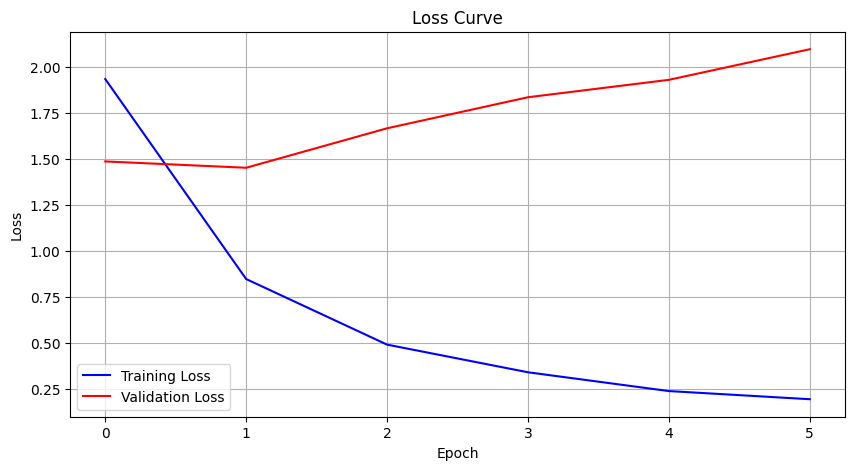

In [13]:

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss", color='b')
plt.plot(val_losses, label="Validation Loss", color='r')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()